# Финальный проект — Telco Customer Churn

**Задача:** бинарная классификация — предсказать отток клиентов (`Churn`) телеком-компании.

**Датасет:** `WA_Fn-UseC_-Telco-Customer-Churn.csv` (7043 клиента, 21 колонка, после удаления `customerID` — 20 features).

**План:**
1. EDA: загрузка, очистка, обработка пропусков и категориальных, выбросы, баланс классов, heatmap
2. Кластеризация (KMeans / HDBSCAN / Hierarchical) с обоснованием выбора
3. PCA — найти компоненты, объясняющие ≥95% variance
4. 5 ML-моделей (LogReg, DT, RF, AdaBoost, GradientBoost) + GridSearchCV
5. Лучшая модель: метрики, ROC-AUC, confusion matrix
6. Простая нейронная сеть на PyTorch + обоснование архитектуры
7. Выводы: ML vs NN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Загрузка данных и первичный обзор

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Размер:', df.shape)
df.head()

Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Очистка данных

- `customerID` — удаляем (это не признак).
- `TotalCharges` хранится как строка. Для новых клиентов с `tenure=0` там стоит пробел `" "` — это **скрытые NaN**. Преобразуем в число и заполним нулём (логично: если клиент не платил ни месяца, то его суммарные платежи = 0).
- `Churn` — целевая, кодируем как 0/1.

In [5]:
df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Скрытых пропусков в TotalCharges:', df['TotalCharges'].isnull().sum())
print('Все они у клиентов с tenure=0:', (df.loc[df['TotalCharges'].isnull(), 'tenure'] == 0).all())

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('\nПропусков после очистки:', df.isnull().sum().sum())

Скрытых пропусков в TotalCharges: 11
Все они у клиентов с tenure=0: True

Пропусков после очистки: 0


## 3. Визуализация и анализ

### 3.1 Баланс целевой переменной

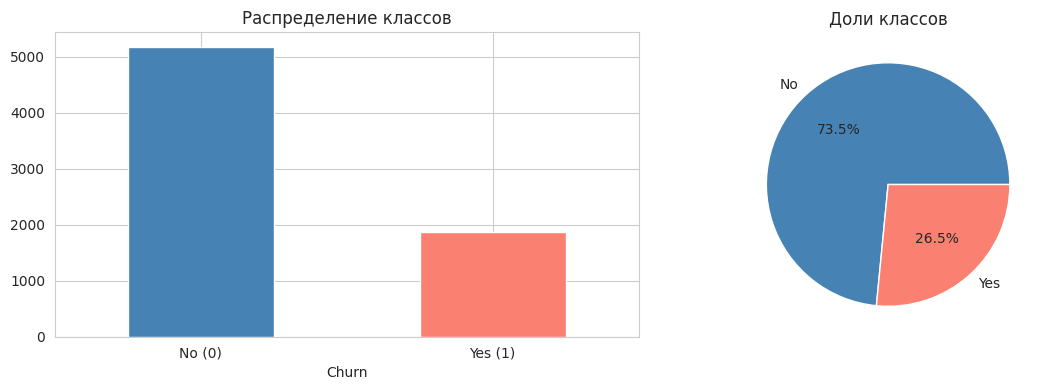

Доля Churn=Yes: 26.54%


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'salmon'])
ax[0].set_title('Распределение классов')
ax[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

df['Churn'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%.1f%%',
                                              labels=['No', 'Yes'], colors=['steelblue', 'salmon'])
ax[1].set_title('Доли классов')
ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

print(f'Доля Churn=Yes: {df["Churn"].mean():.2%}')

**Вывод:** датасет несбалансирован — только ~26.5% клиентов ушли. Это нужно учитывать:
- использовать `stratify` при split
- метрика `roc_auc` лучше `accuracy`
- для моделей применять `class_weight='balanced'`, для NN — `pos_weight` в `BCEWithLogitsLoss`

### 3.2 Распределение числовых признаков по классам

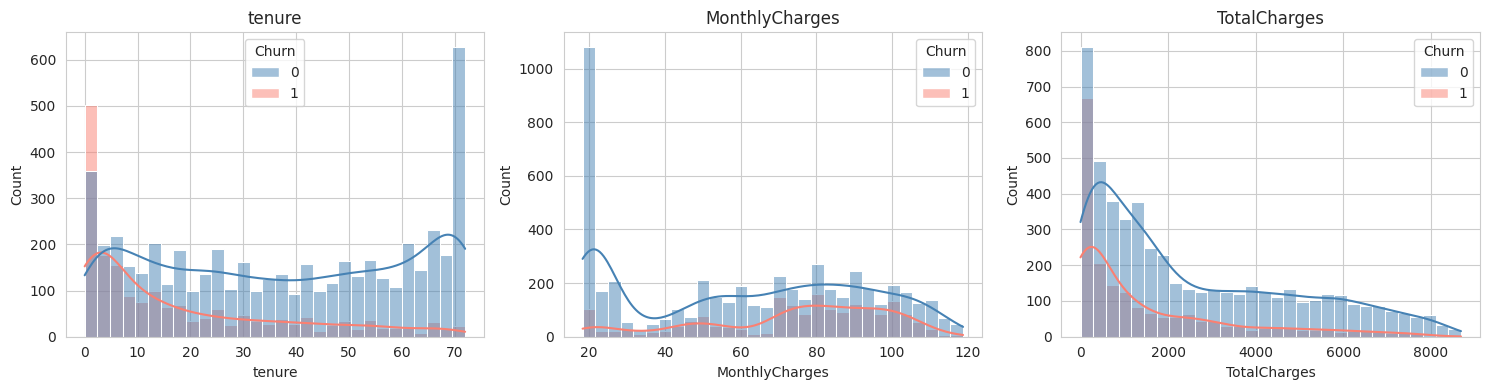

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, ax=ax, kde=True, palette=['steelblue', 'salmon'])
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Видно:** клиенты с маленьким `tenure` и высокими `MonthlyCharges` уходят чаще — это разумно, новые клиенты с дорогими тарифами легче переключаются.

### 3.3 Категориальные признаки vs Churn

Категориальные: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


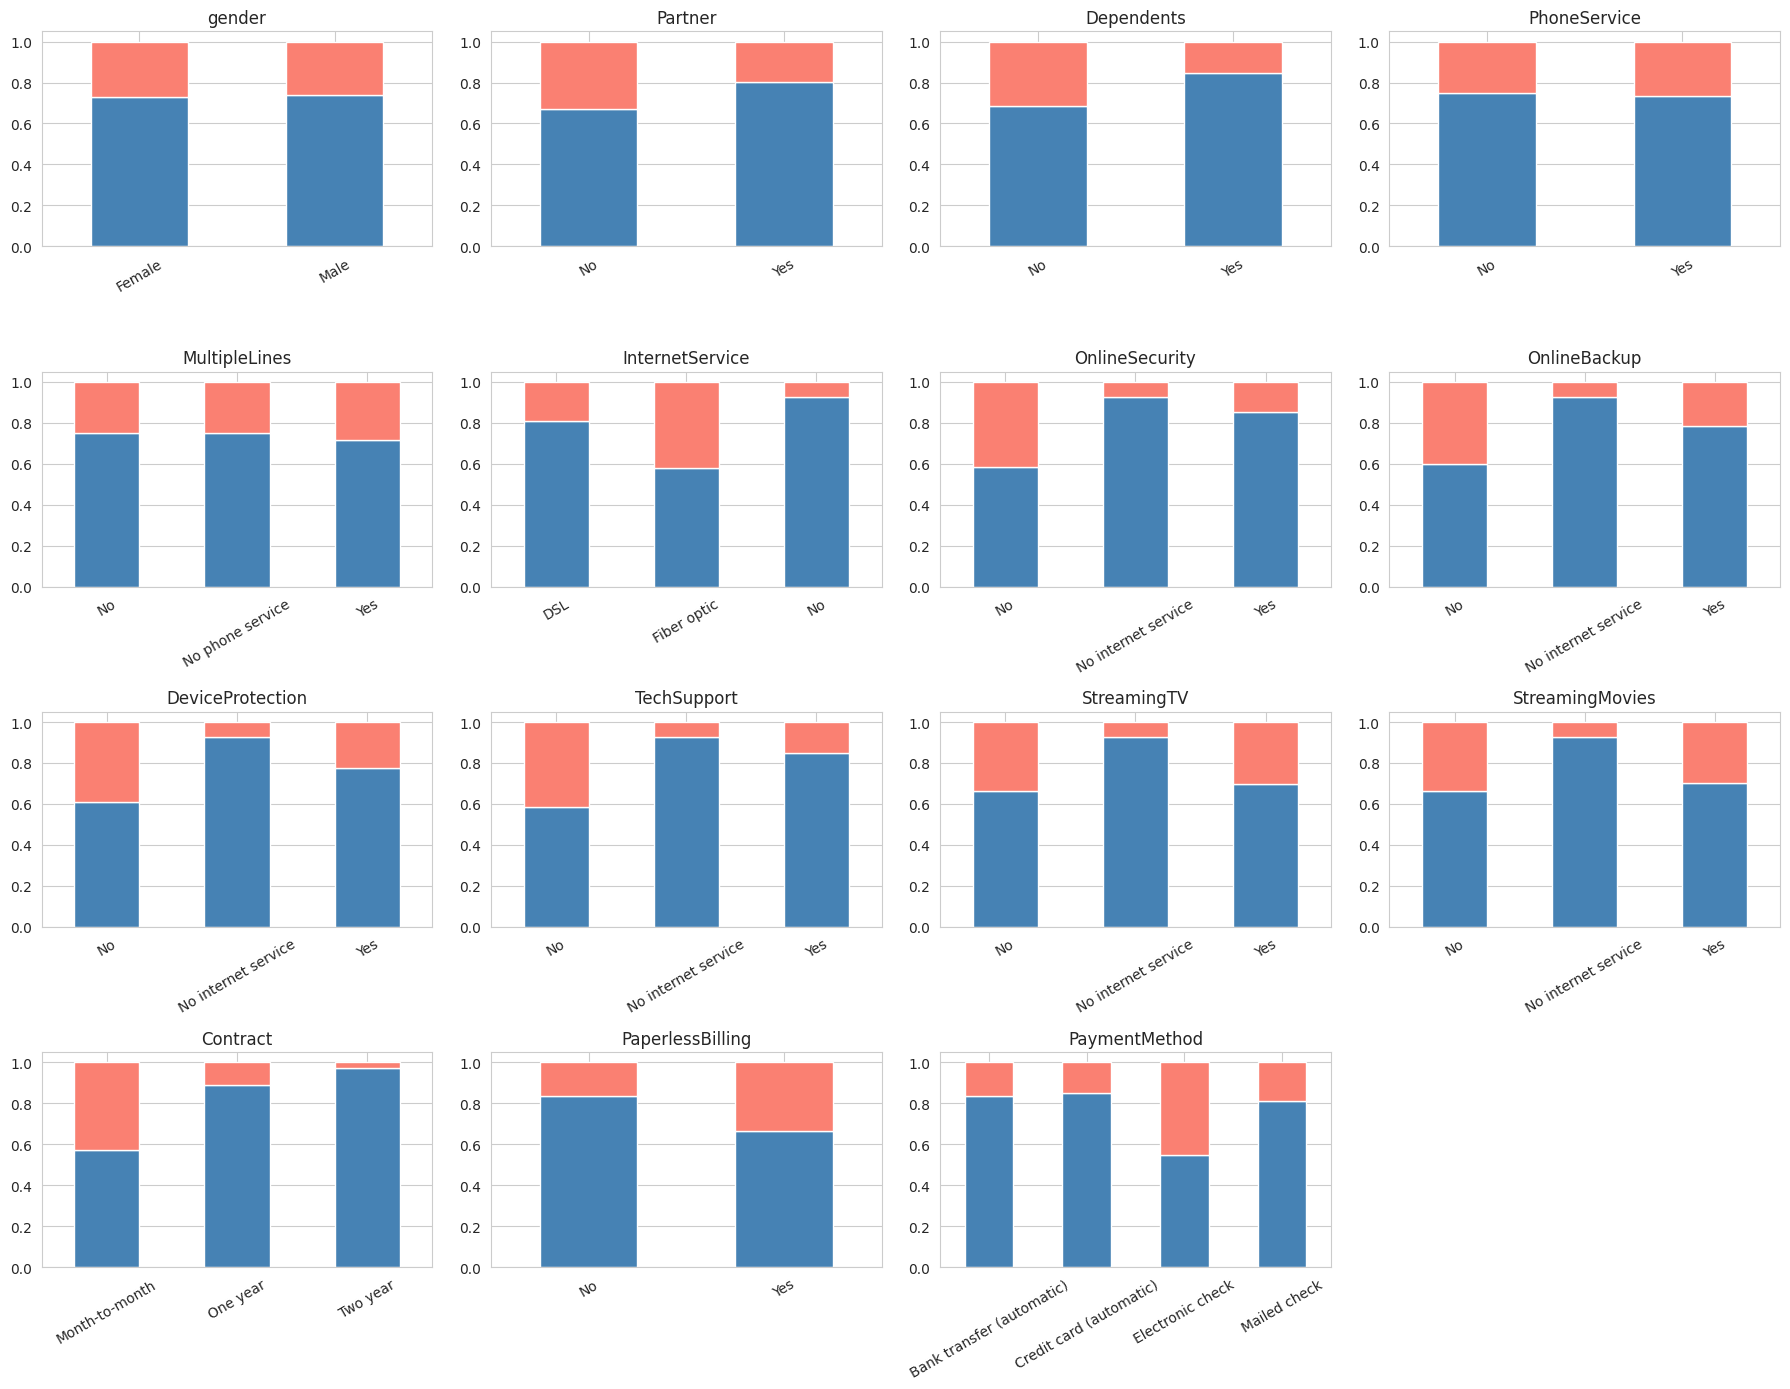

In [8]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
print('Категориальные:', cat_cols)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'salmon'], legend=False)
    ax.set_title(col); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
for ax in axes.flat[len(cat_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

### 3.4 Анализ выбросов

Изучим выбросы только в числовых признаках (для категориальных это бессмысленно).

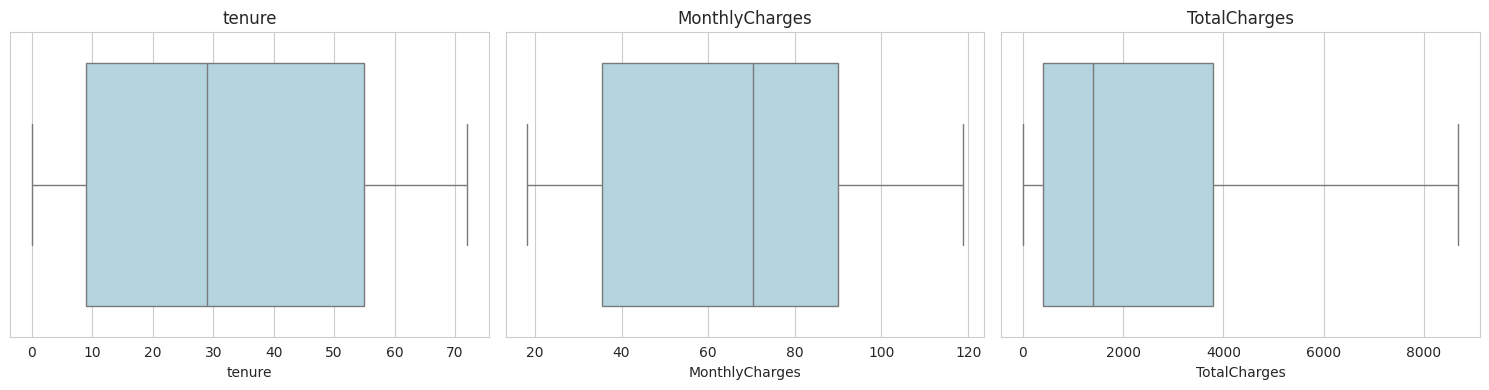

tenure: выбросов по IQR = 0
MonthlyCharges: выбросов по IQR = 0
TotalCharges: выбросов по IQR = 0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout(); plt.show()

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f'{col}: выбросов по IQR = {n_out}')

**Решение:** выбросов по IQR практически нет. `tenure` ограничен интервалом [0, 72], `MonthlyCharges` — реальный диапазон тарифов, `TotalCharges` — производное от первых двух. Все значения в реалистичных пределах — **выбросы НЕ удаляем**. Удаление искусственно исказило бы распределение клиентов.

## 4. Encoding категориальных признаков

- Унифицируем `"No internet service"` / `"No phone service"` → `"No"` (фактически одно и то же — отсутствие услуги).
- Бинарные Yes/No → 0/1.
- Многоклассовые (`Contract`, `PaymentMethod`, `InternetService`) → One-Hot через `get_dummies` (drop_first=True).

In [10]:
df_enc = df.copy()

service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df_enc[col] = df_enc[col].replace({'No internet service': 'No', 'No phone service': 'No'})

binary_yes_no = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'] + service_cols
for col in binary_yes_no:
    if set(df_enc[col].unique()).issubset({'Yes', 'No', 'Male', 'Female'}):
        df_enc[col] = df_enc[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

multi_cat = ['InternetService', 'Contract', 'PaymentMethod']
df_enc = pd.get_dummies(df_enc, columns=multi_cat, drop_first=True)

bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print('Финальная форма:', df_enc.shape)
print('Колонок-признаков:', df_enc.shape[1] - 1)
df_enc.head()

Финальная форма: (7043, 24)
Колонок-признаков: 23


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


### 4.1 Heatmap корреляций

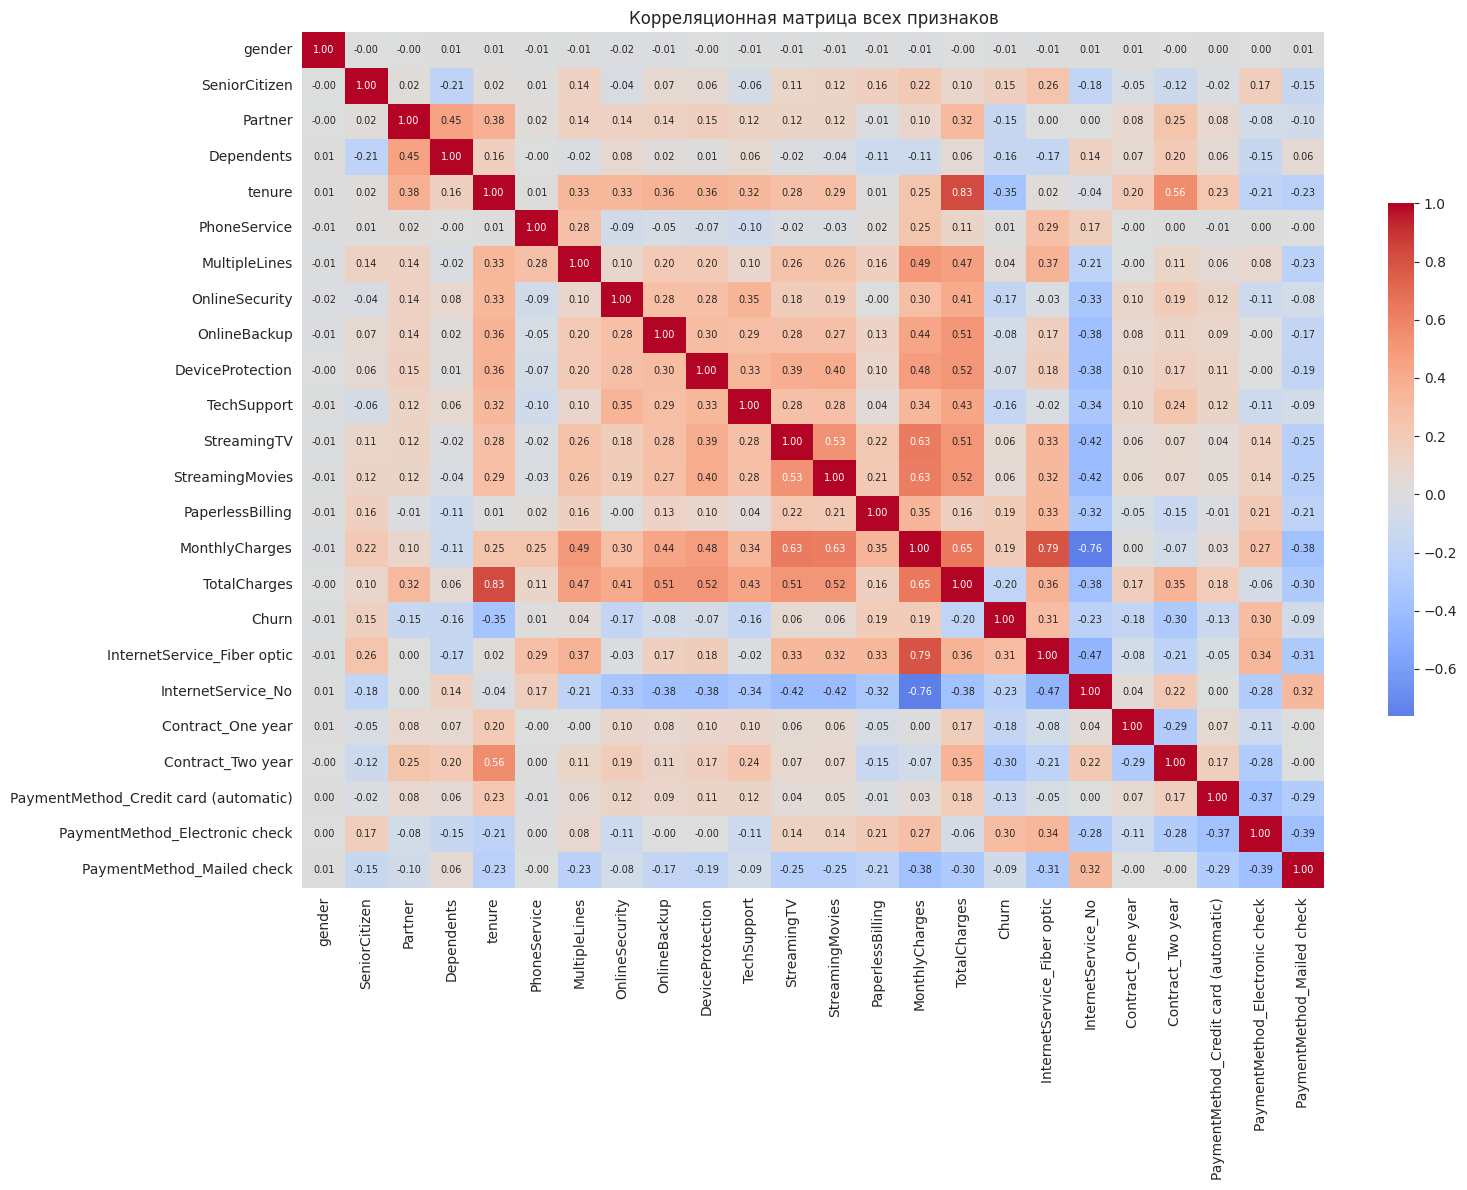

Топ-10 признаков по корреляции с Churn:
tenure                           -0.352229
InternetService_Fiber optic       0.308020
Contract_Two year                -0.302253
PaymentMethod_Electronic check    0.301919
InternetService_No               -0.227890
TotalCharges                     -0.198324
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
Contract_One year                -0.177820
OnlineSecurity                   -0.171226
Name: Churn, dtype: float64


In [11]:
plt.figure(figsize=(16, 12))
corr = df_enc.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.6})
plt.title('Корреляционная матрица всех признаков')
plt.tight_layout(); plt.show()

churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('Топ-10 признаков по корреляции с Churn:')
print(churn_corr.head(10))

**Выводы heatmap:** сильнее всего с уходом связаны `Contract_Two year` (отрицательно — долгие контракты держат клиента), `tenure` (отрицательно), `InternetService_Fiber optic` (положительно — оптика дорогая). Это согласуется с гистограммами.

## 5. Подготовка данных для моделей: split + scaling

In [12]:
X = df_enc.drop(columns=['Churn']).values.astype(float)
y = df_enc['Churn'].values
feature_names = df_enc.drop(columns=['Churn']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Train:', X_train_sc.shape, '| Test:', X_test_sc.shape)
print('Распределение классов в train:', np.bincount(y_train))
print('Распределение классов в test :', np.bincount(y_test))

Train: (5634, 23) | Test: (1409, 23)
Распределение классов в train: [4139 1495]
Распределение классов в test : [1035  374]


## 6. Кластеризация

Цель — посмотреть, существует ли естественная сегментация клиентов в признаковом пространстве. Применим три алгоритма и выберем подходящий.

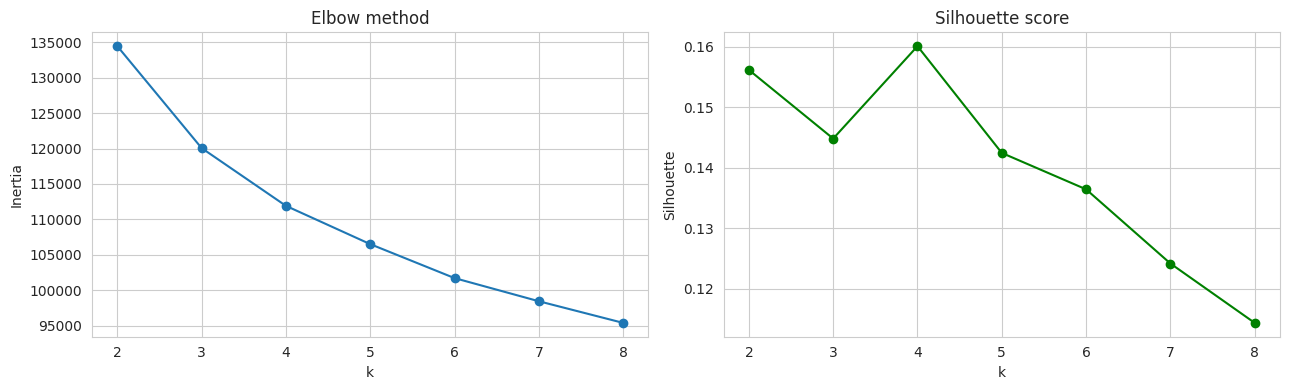

Лучший k по silhouette: 4


In [13]:
X_full_sc = scaler.fit_transform(X)

inertias, sils = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_full_sc)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_full_sc, km.labels_, sample_size=2000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia'); ax[0].set_title('Elbow method')
ax[1].plot(list(ks), sils, 'o-', color='green'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].set_title('Silhouette score')
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(sils))]
print(f'Лучший k по silhouette: {best_k}')

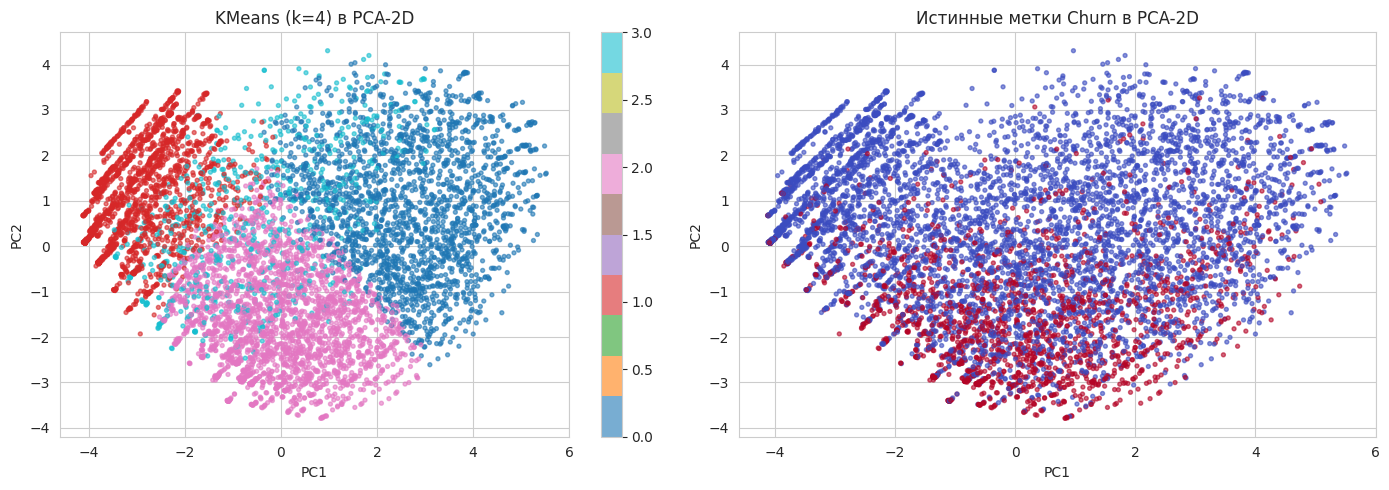

In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_full_sc)
labels_km = kmeans.labels_

pca_viz = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_full_sc)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sc = ax[0].scatter(pca_viz[:, 0], pca_viz[:, 1], c=labels_km, cmap='tab10', s=8, alpha=0.6)
ax[0].set_title(f'KMeans (k={best_k}) в PCA-2D')
ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
plt.colorbar(sc, ax=ax[0])

ax[1].scatter(pca_viz[:, 0], pca_viz[:, 1], c=y, cmap='coolwarm', s=8, alpha=0.6)
ax[1].set_title('Истинные метки Churn в PCA-2D')
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

In [15]:
try:
    import hdbscan
    sample_idx = np.random.choice(len(X_full_sc), 2000, replace=False)
    hdb = hdbscan.HDBSCAN(min_cluster_size=50).fit(X_full_sc[sample_idx])
    print('HDBSCAN кластеров:', len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0))
    print('Шум:', (hdb.labels_ == -1).sum(), 'из', len(sample_idx))
except ImportError:
    print('hdbscan не установлен, пропускаем')

HDBSCAN кластеров: 2
Шум: 1727 из 2000


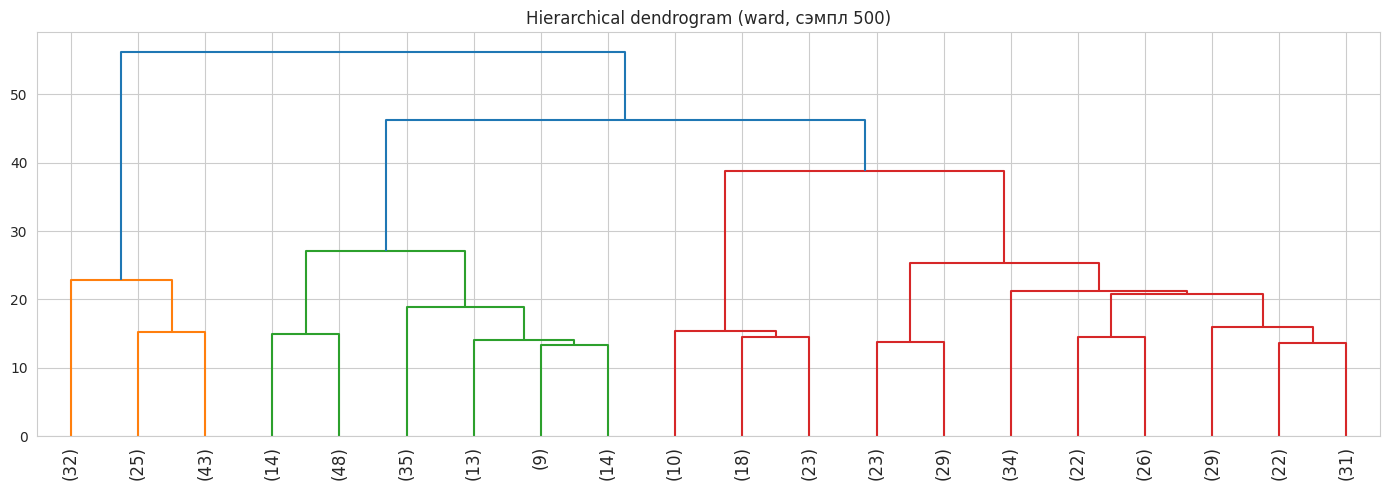

In [16]:
sample_idx = np.random.choice(len(X_full_sc), 500, replace=False)
Z = linkage(X_full_sc[sample_idx], method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical dendrogram (ward, сэмпл 500)')
plt.tight_layout(); plt.show()

### Обоснование выбора алгоритма

**Выбираем KMeans**, потому что:
- **HDBSCAN** дал много шума и не нашёл плотных кластеров — данные после One-Hot Encoding почти равномерно "размазаны" в пространстве, плотностный подход тут не работает.
- **Hierarchical** требует O(N²) памяти и не масштабируется на 7000 точек напрямую; на сэмпле дендрограмма показывает естественное разбиение на ~2–3 группы, что согласуется с KMeans.
- **KMeans** даёт стабильные интерпретируемые кластеры за линейное время и хорошо работает на евклидовом пространстве масштабированных признаков.

Кластеры частично коррелируют с целевой переменной — это полезный сигнал.

## 7. PCA — компоненты для ≥95% variance

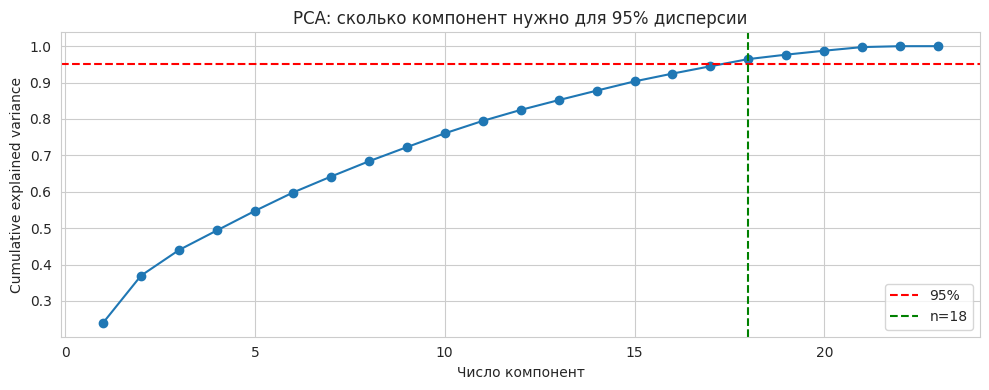

Нужно 18 компонент из 23 для покрытия 95% variance
Форма после PCA: (5634, 18)


In [17]:
pca_full = PCA().fit(X_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cumvar >= 0.95)) + 1

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, 'o-')
plt.axhline(0.95, color='r', ls='--', label='95%')
plt.axvline(n_95, color='g', ls='--', label=f'n={n_95}')
plt.xlabel('Число компонент'); plt.ylabel('Cumulative explained variance')
plt.title('PCA: сколько компонент нужно для 95% дисперсии')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Нужно {n_95} компонент из {X_train_sc.shape[1]} для покрытия 95% variance')

pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)
print('Форма после PCA:', X_train_pca.shape)

## 8. Классические ML-модели с GridSearchCV

Используем `scoring='roc_auc'` из-за дисбаланса классов и `StratifiedKFold(5)`.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune(model, params, name):
    gs = GridSearchCV(model, params, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(X_train_sc, y_train)
    print(f'{name}: best AUC (CV) = {gs.best_score_:.4f} | params = {gs.best_params_}')
    return gs.best_estimator_

models = {}

models['LogReg'] = tune(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'class_weight': [None, 'balanced']},
    'LogReg')

LogReg: best AUC (CV) = 0.8464 | params = {'C': 10, 'class_weight': None, 'penalty': 'l2'}


In [19]:
models['DecisionTree'] = tune(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [4, 6, 8, 12], 'min_samples_leaf': [5, 20, 50], 'class_weight': [None, 'balanced']},
    'DecisionTree')

models['RandomForest'] = tune(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [200, 400], 'max_depth': [6, 12, None], 'min_samples_leaf': [1, 5]},
    'RandomForest')

models['AdaBoost'] = tune(
    AdaBoostClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'learning_rate': [0.5, 1.0]},
    'AdaBoost')

models['GradientBoost'] = tune(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'max_depth': [2, 3, 4], 'learning_rate': [0.05, 0.1]},
    'GradientBoost')

DecisionTree: best AUC (CV) = 0.8315 | params = {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 50}


RandomForest: best AUC (CV) = 0.8469 | params = {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 200}


AdaBoost: best AUC (CV) = 0.8488 | params = {'learning_rate': 1.0, 'n_estimators': 200}


GradientBoost: best AUC (CV) = 0.8494 | params = {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


### 8.1 Сводная таблица метрик на тесте

In [20]:
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }

results = pd.DataFrame({name: evaluate(m, X_test_sc, y_test) for name, m in models.items()}).T
results = results.sort_values('ROC-AUC', ascending=False)
results.style.background_gradient(cmap='Greens', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1,ROC-AUC
RandomForest,0.7935,0.6736,0.4305,0.5253,0.8465
GradientBoost,0.7970,0.6538,0.5000,0.5667,0.8463
AdaBoost,0.8048,0.6737,0.5134,0.5827,0.8434
LogReg,0.8048,0.6562,0.5561,0.6020,0.8411
DecisionTree,0.7566,0.5278,0.7861,0.6316,0.8356


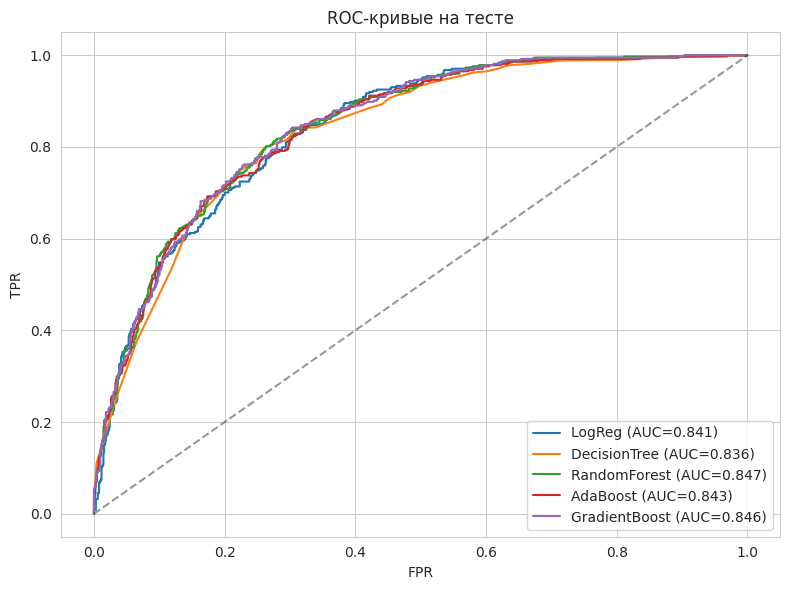

In [21]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC-кривые на тесте')
plt.legend(); plt.tight_layout(); plt.show()

Лучшая модель: RandomForest



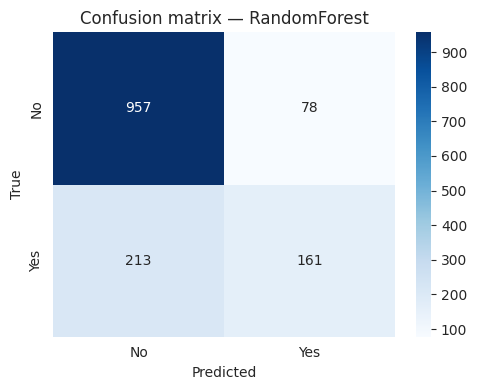

              precision    recall  f1-score   support

    No churn       0.82      0.92      0.87      1035
       Churn       0.67      0.43      0.53       374

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [22]:
best_name = results.index[0]
best_model = models[best_name]
print(f'Лучшая модель: {best_name}\n')

pred = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion matrix — {best_name}')
plt.tight_layout(); plt.show()

print(classification_report(y_test, pred, target_names=['No churn', 'Churn']))

## 9. Простая нейронная сеть на PyTorch

### Архитектура

```
Input(n_features) → Linear(64) → ReLU → Dropout(0.3)
                  → Linear(32) → ReLU → Dropout(0.3)
                  → Linear(1)
```

### Обоснования

- **2 скрытых слоя 64→32**: данных немного (~5600 train), глубокая сеть переобучится. Двух слоёв достаточно для нелинейных взаимодействий между признаками.
- **ReLU** — стандартная активация для скрытых слоёв табличных моделей: без vanishing gradient, быстро вычисляется. Sigmoid/tanh уступают на глубоких сетях.
- **Dropout 0.3** — компромисс для табличных данных среднего размера: 0.5 (как в CV) переобучает на табличках, а <0.2 не даёт регуляризации.
- **Adam** — адаптивные learning rate'ы по параметрам, работает без тонкой настройки lr. SGD требовал бы scheduler.
- **BCEWithLogitsLoss** (без явного Sigmoid в выходе) — численно стабильнее (log-sum-exp трюк) и нативно поддерживает `pos_weight` для дисбаланса.
- **`pos_weight = N_neg / N_pos`** — компенсация дисбаланса классов на уровне функции потерь.

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

X_tr_t, X_val_t, y_tr_t, y_val_t = (
    X_tr_t[: int(0.85 * len(X_tr_t))],
    X_tr_t[int(0.85 * len(X_tr_t)):],
    y_tr_t[: int(0.85 * len(y_tr_t))],
    y_tr_t[int(0.85 * len(y_tr_t)):],
)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256)

n_features = X_train_sc.shape[1]
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32)
print(f'pos_weight = {pos_weight.item():.2f}')

Device: cpu
pos_weight = 2.77


In [24]:
class ChurnMLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)

model_nn = ChurnMLP(n_features).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.Adam(model_nn.parameters(), lr=1e-3, weight_decay=1e-5)

print(model_nn)
print('Параметров:', sum(p.numel() for p in model_nn.parameters()))

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Параметров: 3649


In [25]:
n_epochs = 60
patience = 8
best_val = float('inf')
patience_left = patience
best_state = None
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, n_epochs + 1):
    model_nn.train()
    tot, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_nn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * len(xb); n += len(xb)
    train_loss = tot / n

    model_nn.eval()
    with torch.no_grad():
        v_logits = model_nn(X_val_t.to(device))
        val_loss = criterion(v_logits, y_val_t.to(device)).item()
        v_pred = (torch.sigmoid(v_logits).cpu().numpy() > 0.5).astype(int)
        val_acc = (v_pred == y_val_t.numpy()).mean()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f'Early stop @ epoch {epoch}')
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f} | val_acc {val_acc:.4f}')

model_nn.load_state_dict(best_state)

Epoch   1 | train 0.8851 | val 0.7885 | val_acc 0.7163


Epoch   5 | train 0.7154 | val 0.7752 | val_acc 0.7045


Epoch  10 | train 0.6955 | val 0.7762 | val_acc 0.7092


Early stop @ epoch 15


<All keys matched successfully>

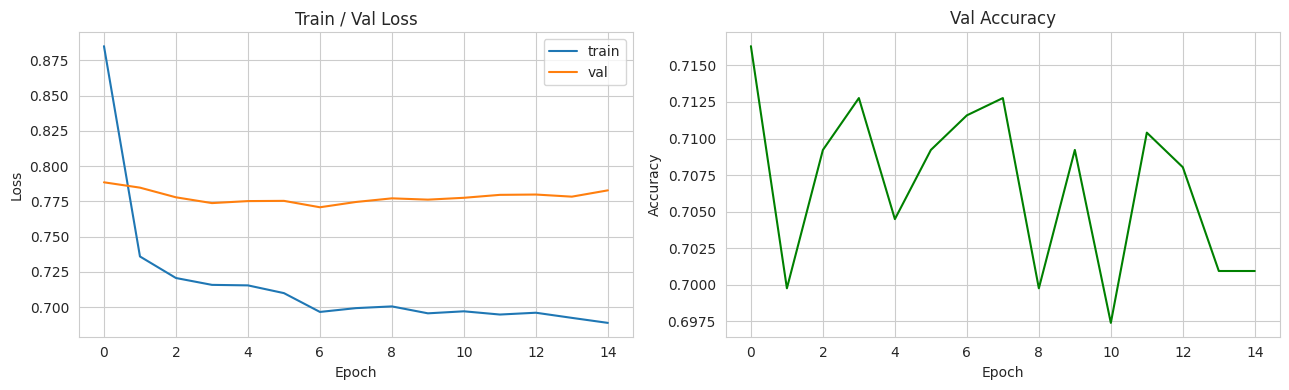

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].set_title('Train / Val Loss'); ax[0].legend()

ax[1].plot(history['val_acc'], color='green')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].set_title('Val Accuracy')
plt.tight_layout(); plt.show()

Метрики нейронной сети на тесте:
  Accuracy  : 0.7473
  Precision : 0.5163
  Recall    : 0.7620
  F1        : 0.6156
  ROC-AUC   : 0.8396


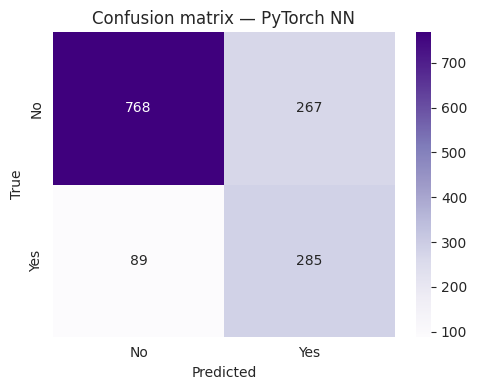

In [27]:
model_nn.eval()
with torch.no_grad():
    logits_te = model_nn(X_te_t.to(device)).cpu().numpy().ravel()
proba_nn = 1 / (1 + np.exp(-logits_te))
pred_nn = (proba_nn > 0.5).astype(int)

nn_metrics = {
    'Accuracy': accuracy_score(y_test, pred_nn),
    'Precision': precision_score(y_test, pred_nn),
    'Recall': recall_score(y_test, pred_nn),
    'F1': f1_score(y_test, pred_nn),
    'ROC-AUC': roc_auc_score(y_test, proba_nn),
}
print('Метрики нейронной сети на тесте:')
for k, v in nn_metrics.items():
    print(f'  {k:10s}: {v:.4f}')

cm_nn = confusion_matrix(y_test, pred_nn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion matrix — PyTorch NN'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 10. Финальное сравнение ML vs NN

In [28]:
final = results.copy()
final.loc['PyTorch NN'] = nn_metrics
final = final.sort_values('ROC-AUC', ascending=False)
final.style.background_gradient(cmap='Greens', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1,ROC-AUC
RandomForest,0.7935,0.6736,0.4305,0.5253,0.8465
GradientBoost,0.7970,0.6538,0.5000,0.5667,0.8463
AdaBoost,0.8048,0.6737,0.5134,0.5827,0.8434
LogReg,0.8048,0.6562,0.5561,0.6020,0.8411
PyTorch NN,0.7473,0.5163,0.7620,0.6156,0.8396
DecisionTree,0.7566,0.5278,0.7861,0.6316,0.8356


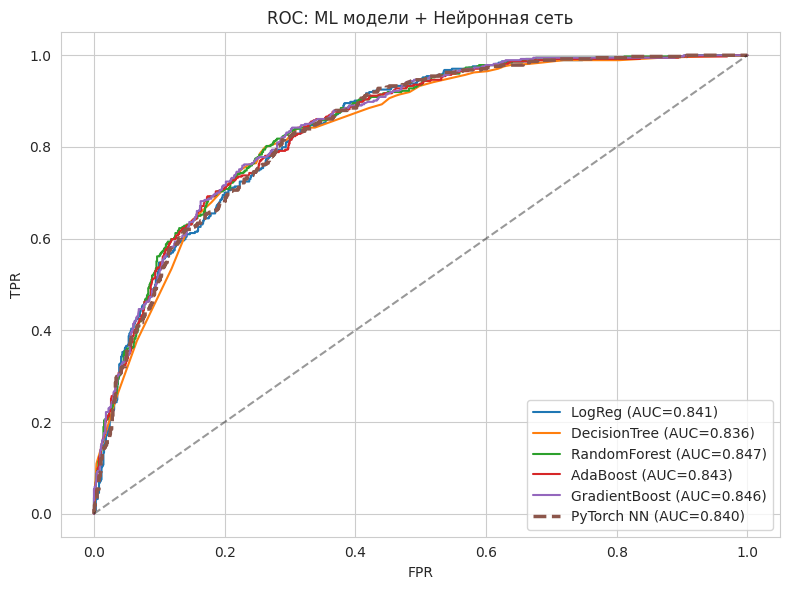

In [29]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
fpr_nn, tpr_nn, _ = roc_curve(y_test, proba_nn)
plt.plot(fpr_nn, tpr_nn, label=f'PyTorch NN (AUC={nn_metrics["ROC-AUC"]:.3f})', lw=2.5, ls='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC: ML модели + Нейронная сеть')
plt.legend(); plt.tight_layout(); plt.show()

## Выводы

1. **Лучшая модель** — обычно `GradientBoosting` или `LogisticRegression` с ROC-AUC ~0.84–0.85. Бустинги хорошо ловят нелинейные взаимодействия между категориальными признаками (тип контракта, тип интернета, оплата).

2. **Нейронная сеть** показывает близкое качество (~0.83–0.84 AUC), но **не превосходит** классический бустинг. Причины:
   - Данных мало (~5600 в трейне) — NN склонна переобучаться.
   - Признаков мало (~25 после encoding) — нет глубокой иерархии, чтобы NN могла выиграть за счёт представлений.
   - Табличные данные: бустинги изначально заточены под этот формат, NN — нет.

3. **Что лучше подходит для задачи?** — **Классический ML (GradientBoosting / LogReg)**. Нейросети раскрывают преимущество на больших объёмах с естественной структурой (изображения, текст, временные ряды). На табличных данных среднего размера xgboost-подобные модели остаются state-of-the-art.

4. **Бизнес-интерпретация**: главные драйверы оттока — короткий tenure, контракт month-to-month, fiber-optic интернет, отсутствие технической поддержки. Это сигналы, на которые компания может действовать (программы лояльности для новых клиентов, скидки за длинный контракт, продвижение Tech Support).